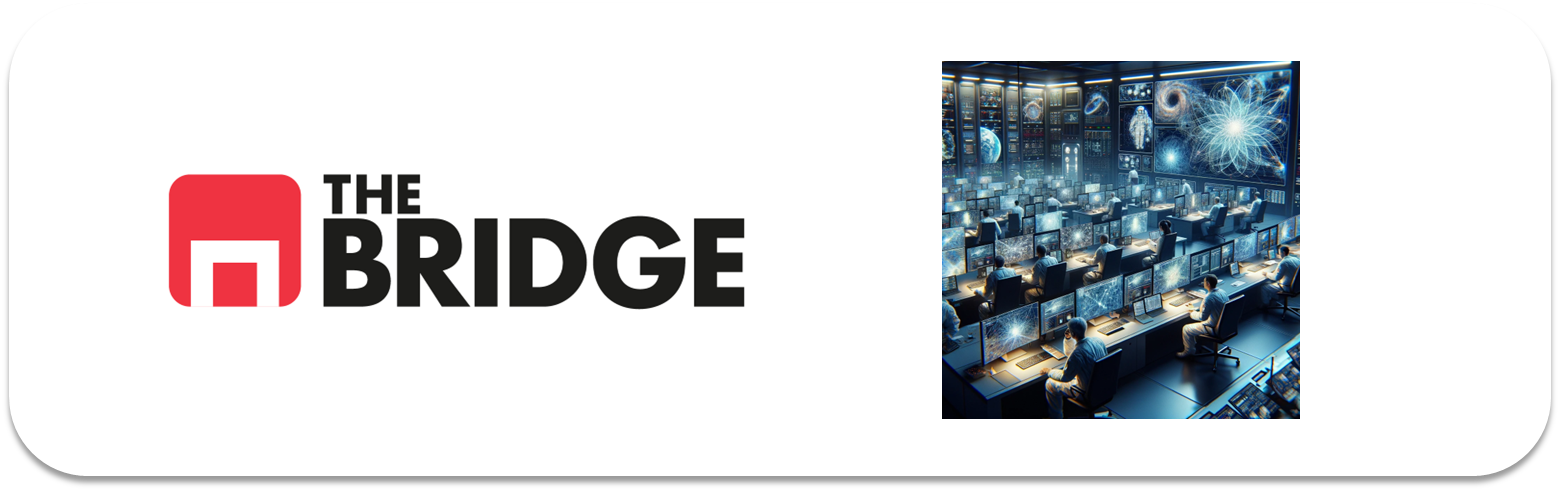

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from keras.utils import load_img, img_to_array
import keras
from sklearn.metrics import classification_report, confusion_matrix

BASE_PATH = Path("data")
print(BASE_PATH.exists())  # debe imprimir True

True


### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



Leyendo github_train_0...
  → 1000 imágenes cargadas
Leyendo github_train_1...
  → 1000 imágenes cargadas
Leyendo github_train_2...
  → 1000 imágenes cargadas
Leyendo github_train_3...
  → 1000 imágenes cargadas

X_train shape: (4000, 32, 32, 3)
y_train shape: (4000,)
Distribución → cats: 2000, dogs: 2000

Leyendo github_test...
X_test shape: (1000, 32, 32, 3)
y_test shape: (1000,)
Distribución → cats: 500, dogs: 500


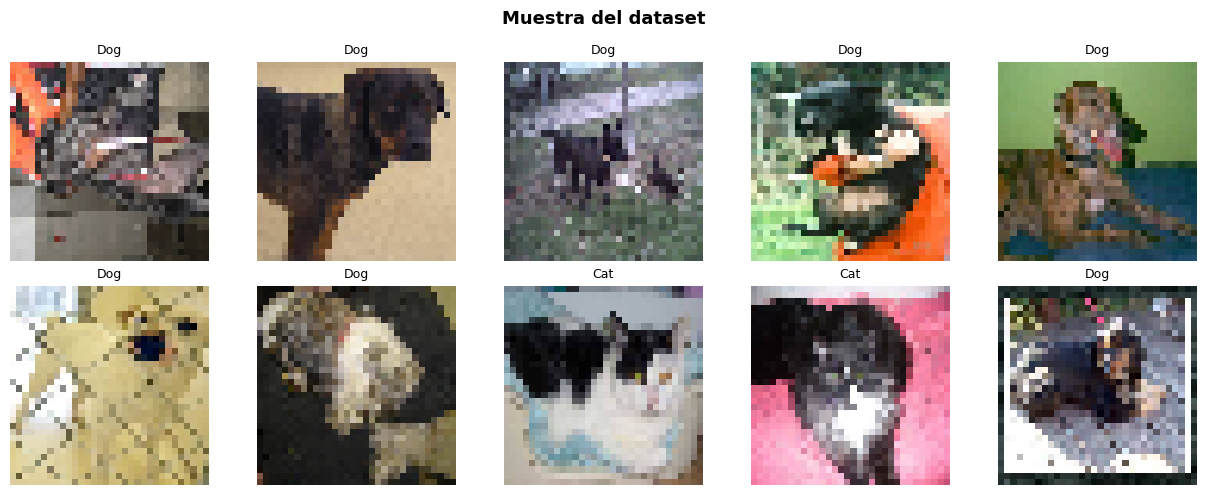

In [9]:


def cargar_imagenes_directorio(directorio, img_size=32):
    """
    Lee todas las imágenes de un directorio con Keras,
    las redimensiona a img_size x img_size y extrae la
    etiqueta del nombre del archivo (cat=0, dog=1).
    """
    imagenes  = []
    etiquetas = []

    directorio = Path(directorio)

    for filepath in sorted(directorio.iterdir()):

        if filepath.suffix.lower() not in ['.jpg', '.jpeg', '.png']:
            continue

        nombre = filepath.name.lower()
        if nombre.startswith('cat'):
            etiqueta = 0
        elif nombre.startswith('dog'):
            etiqueta = 1
        else:
            print(f"⚠️ Ignorado: {filepath.name}")
            continue

        # load_img lee la imagen y la redimensiona directamente
        # color_mode='rgb' garantiza 3 canales (por si alguna es RGBA o grises)
        img = load_img(filepath, target_size=(img_size, img_size), color_mode='rgb')

        # Convertimos a array numpy → shape (32, 32, 3)
        img = img_to_array(img)

        imagenes.append(img)
        etiquetas.append(etiqueta)

    return imagenes, etiquetas


# =============================================================
# CARGAR TRAIN (4 directorios)
# =============================================================
train_dirs = [
    BASE_PATH / "github_train_0",
    BASE_PATH / "github_train_1",
    BASE_PATH / "github_train_2",
    BASE_PATH / "github_train_3",
]

todas_imagenes_train = []
todas_etiquetas_train = []

for directorio in train_dirs:
    print(f"Leyendo {directorio.name}...")
    imgs, labels = cargar_imagenes_directorio(directorio, IMG_SIZE)
    todas_imagenes_train.extend(imgs)
    todas_etiquetas_train.extend(labels)
    print(f"  → {len(imgs)} imágenes cargadas")

X_train = np.array(todas_imagenes_train)
y_train = np.array(todas_etiquetas_train)

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Distribución → cats: {(y_train==0).sum()}, dogs: {(y_train==1).sum()}")


# =============================================================
# CARGAR TEST
# =============================================================
print(f"\nLeyendo github_test...")
X_test_list, y_test_list = cargar_imagenes_directorio(BASE_PATH / "github_test", IMG_SIZE)

X_test = np.array(X_test_list)
y_test = np.array(y_test_list)

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Distribución → cats: {(y_test==0).sum()}, dogs: {(y_test==1).sum()}")


# =============================================================
# NORMALIZACIÓN
# =============================================================
X_train_norm = X_train / 255.0
X_test_norm  = X_test  / 255.0


# =============================================================
# VISUALIZACIÓN
# =============================================================
def visualizar_muestra(X, y, class_names={0:'Cat', 1:'Dog'}, n=10, cols=5):
    indices = np.random.choice(len(X), size=n, replace=False)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.5, rows*2.5))
    axes = np.array(axes).flatten()

    for i, idx in enumerate(indices):
        axes[i].imshow(X[idx].astype('uint8'))  # imshow necesita uint8 para mostrar bien
        axes[i].set_title(class_names[y[idx]], fontsize=9)
        axes[i].axis('off')

    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.suptitle("Muestra del dataset", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualizar_muestra(X_train, y_train, n=10)

MINI EDA DEL DATASET

 Shape X_train: (4000, 32, 32, 3)
 Shape X_test:  (1000, 32, 32, 3)

  Clases train → cats: 2000, dogs: 2000
  Clases test  → cats: 500,  dogs: 500

 Rango de píxeles (sin normalizar):
   min: 0.0, max: 255.0

 Media de píxeles por canal (R, G, B):
   R: 124.8
   G: 116.1
   B: 106.5


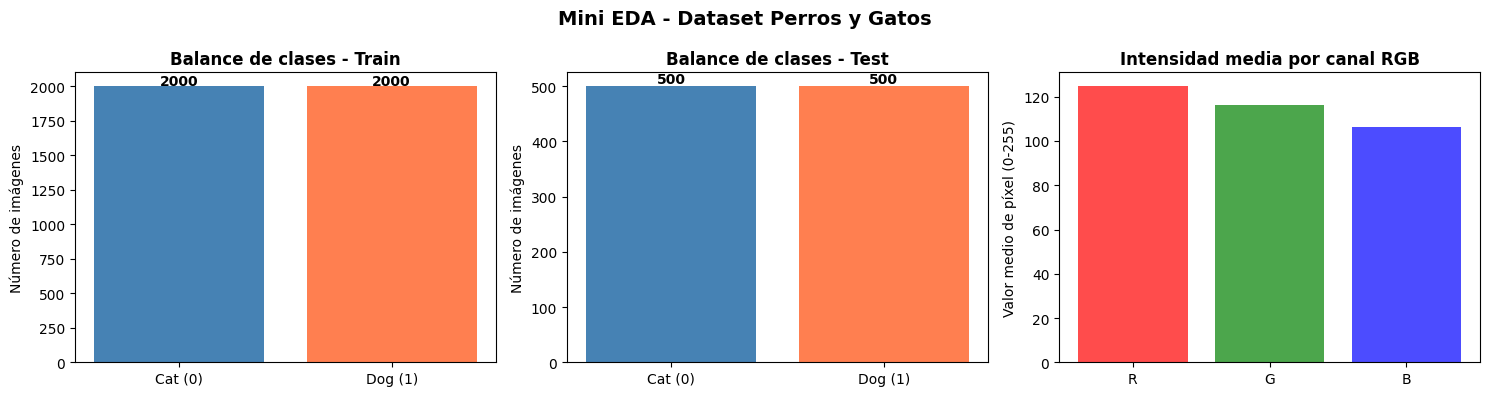

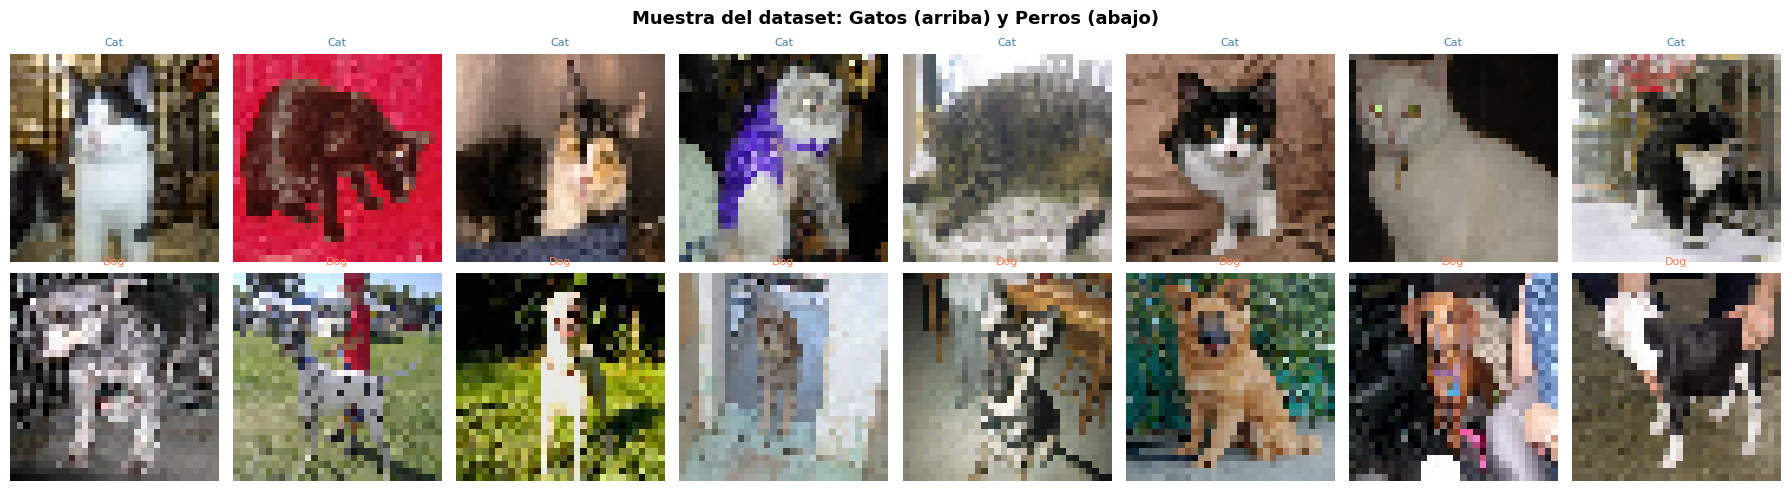

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 543,937 (2.07 MB)

 Trainable params: 543,937 (2.07 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:


# =============================================================
# MINI EDA - Análisis exploratorio
# =============================================================

print("="*50)
print("MINI EDA DEL DATASET")
print("="*50)

print(f"\n Shape X_train: {X_train.shape}")
print(f" Shape X_test:  {X_test.shape}")
print(f"\n  Clases train → cats: {(y_train==0).sum()}, dogs: {(y_train==1).sum()}")
print(f"  Clases test  → cats: {(y_test==0).sum()},  dogs: {(y_test==1).sum()}")
print(f"\n Rango de píxeles (sin normalizar):")
print(f"   min: {X_train.min()}, max: {X_train.max()}")
print(f"\n Media de píxeles por canal (R, G, B):")
print(f"   R: {X_train[:,:,:,0].mean():.1f}")
print(f"   G: {X_train[:,:,:,1].mean():.1f}")
print(f"   B: {X_train[:,:,:,2].mean():.1f}")


# --- Distribución de clases (gráfico de barras) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfico 1: balance de clases en train
axes[0].bar(['Cat (0)', 'Dog (1)'],
            [(y_train==0).sum(), (y_train==1).sum()],
            color=['steelblue', 'coral'])
axes[0].set_title('Balance de clases - Train', fontweight='bold')
axes[0].set_ylabel('Número de imágenes')
for i, v in enumerate([(y_train==0).sum(), (y_train==1).sum()]):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Gráfico 2: balance de clases en test
axes[1].bar(['Cat (0)', 'Dog (1)'],
            [(y_test==0).sum(), (y_test==1).sum()],
            color=['steelblue', 'coral'])
axes[1].set_title('Balance de clases - Test', fontweight='bold')
axes[1].set_ylabel('Número de imágenes')
for i, v in enumerate([(y_test==0).sum(), (y_test==1).sum()]):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Gráfico 3: intensidad media por canal RGB
canales = ['R', 'G', 'B']
medias = [X_train[:,:,:,i].mean() for i in range(3)]
colores = ['red', 'green', 'blue']
axes[2].bar(canales, medias, color=colores, alpha=0.7)
axes[2].set_title('Intensidad media por canal RGB', fontweight='bold')
axes[2].set_ylabel('Valor medio de píxel (0-255)')

plt.suptitle('Mini EDA - Dataset Perros y Gatos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# --- Muestra visual del dataset ---
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
class_names = {0: 'Cat', 1: 'Dog'}

# Primera fila: gatos
cat_indices = np.where(y_train == 0)[0][:8]
for i, idx in enumerate(cat_indices):
    axes[0, i].imshow(X_train[idx].astype('uint8'))
    axes[0, i].set_title('Cat', fontsize=8, color='steelblue')
    axes[0, i].axis('off')

# Segunda fila: perros
dog_indices = np.where(y_train == 1)[0][:8]
for i, idx in enumerate(dog_indices):
    axes[1, i].imshow(X_train[idx].astype('uint8'))
    axes[1, i].set_title('Dog', fontsize=8, color='coral')
    axes[1, i].axis('off')

plt.suptitle('Muestra del dataset: Gatos (arriba) y Perros (abajo)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# =============================================================
# CONSTRUCCIÓN DEL MODELO CNN
# =============================================================

model_cnn = keras.Sequential([

    keras.Input(shape=(32, 32, 3)),  # imágenes RGB de 32x32

    # --- Bloque 1: Conv + Pooling ---
    # 32 filtros de 3×3. Cada filtro aprende a detectar un patrón.
    # 'same' padding mantiene el tamaño espacial tras la convolución.
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    # MaxPooling 2×2: coge el máximo de cada bloque 2×2.
    # Reduce (32,32) → (16,16). Menos parámetros y más robustez.
    keras.layers.MaxPooling2D((2, 2)),

    # --- Bloque 2: Conv + Pooling ---
    # 64 filtros: capas más profundas aprenden patrones más complejos.
    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    # Reduce (16,16) → (8,8)
    keras.layers.MaxPooling2D((2, 2)),

    # --- Clasificador ---
    # Flatten: convierte (8, 8, 64) → vector de 4096 valores
    keras.layers.Flatten(),

    # Capa densa para combinar las features aprendidas por las conv
    keras.layers.Dense(128, activation='relu'),

    # Salida: 1 neurona con Sigmoid → probabilidad de ser perro
    # > 0.5 = perro (1), < 0.5 = gato (0)
    keras.layers.Dense(1, activation='sigmoid')
])

model_cnn.compile(
    optimizer='adam',
    # binary_crossentropy es el loss estándar para clasificación BINARIA
    # (equivalente a sparse_categorical_crossentropy pero para 2 clases)
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6234 - loss: 0.6678 - val_accuracy: 0.0000e+00 - val_loss: 1.4107
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6612 - loss: 0.6193 - val_accuracy: 0.1187 - val_loss: 1.2454
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7084 - loss: 0.5702 - val_accuracy: 0.5700 - val_loss: 0.6942
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7322 - loss: 0.5292 - val_accuracy: 0.5800 - val_loss: 0.6898
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7688 - loss: 0.4857 - val_accuracy: 0.6575 - val_loss: 0.6311
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7859 - loss: 0.4474 - val_accuracy: 0.6000 - val_loss: 0.7434
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8084 - loss: 0.4229 - val_accuracy: 0.5013 - val_loss: 0.9250
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8375 - loss: 0.3651 - val_accuracy

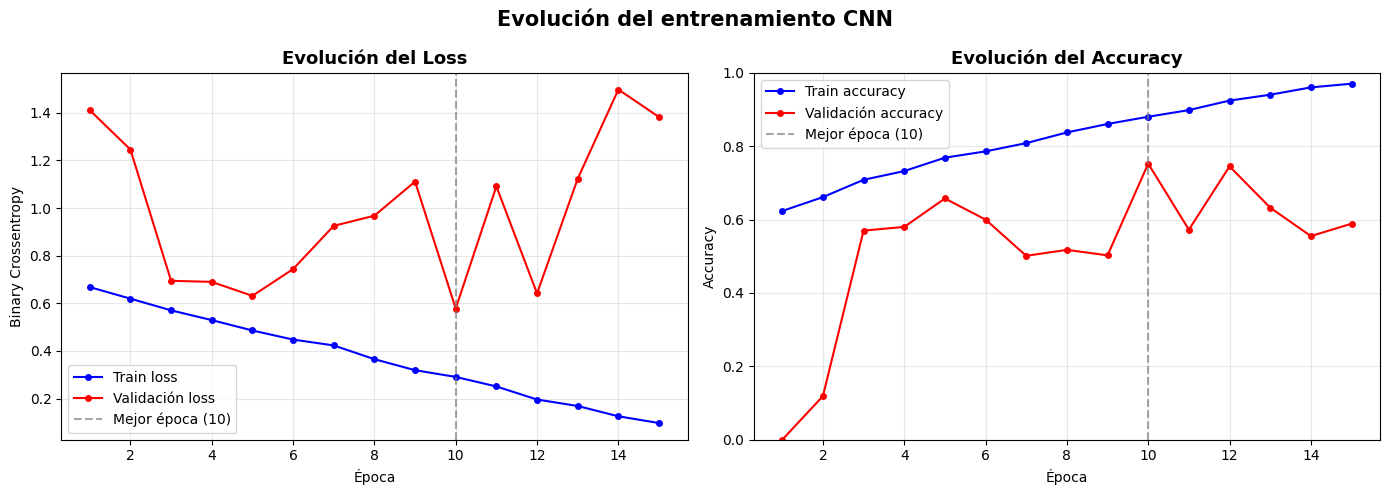


  Épocas entrenadas:       15
  Mejor época (val_loss):  10
  Mejor val_loss:          0.5777
  Mejor val_accuracy:      0.7525  (75.25%)


In [13]:
# =============================================================
# ENTRENAMIENTO
# =============================================================

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_cnn = model_cnn.fit(
    X_train_norm,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)


# =============================================================
# GRÁFICAS DE EVOLUCIÓN
# =============================================================

def plot_training_history(history):
    loss_train = history.history['loss']
    loss_val   = history.history['val_loss']
    acc_train  = history.history['accuracy']
    acc_val    = history.history['val_accuracy']

    epocas     = range(1, len(loss_train) + 1)
    best_epoch = loss_val.index(min(loss_val)) + 1

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- Loss ---
    ax1.plot(epocas, loss_train, 'b-o', markersize=4, label='Train loss')
    ax1.plot(epocas, loss_val,   'r-o', markersize=4, label='Validación loss')
    ax1.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7,
                label=f'Mejor época ({best_epoch})')
    ax1.set_title('Evolución del Loss', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Binary Crossentropy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- Accuracy ---
    ax2.plot(epocas, acc_train, 'b-o', markersize=4, label='Train accuracy')
    ax2.plot(epocas, acc_val,   'r-o', markersize=4, label='Validación accuracy')
    ax2.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7,
                label=f'Mejor época ({best_epoch})')
    ax2.set_title('Evolución del Accuracy', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim([0, 1])
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle('Evolución del entrenamiento CNN', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\n{'='*45}")
    print(f"  Épocas entrenadas:       {len(loss_train)}")
    print(f"  Mejor época (val_loss):  {best_epoch}")
    print(f"  Mejor val_loss:          {min(loss_val):.4f}")
    print(f"  Mejor val_accuracy:      {max(acc_val):.4f}  ({max(acc_val)*100:.2f}%)")
    print(f"{'='*45}")

plot_training_history(history_cnn)

  Loss en test:      0.6051
  Accuracy en test:  0.7310  (73.10%)

Classification Report:
              precision    recall  f1-score   support

     Cat (0)       0.73      0.73      0.73       500
     Dog (1)       0.73      0.73      0.73       500

    accuracy                           0.73      1000
   macro avg       0.73      0.73      0.73      1000
weighted avg       0.73      0.73      0.73      1000



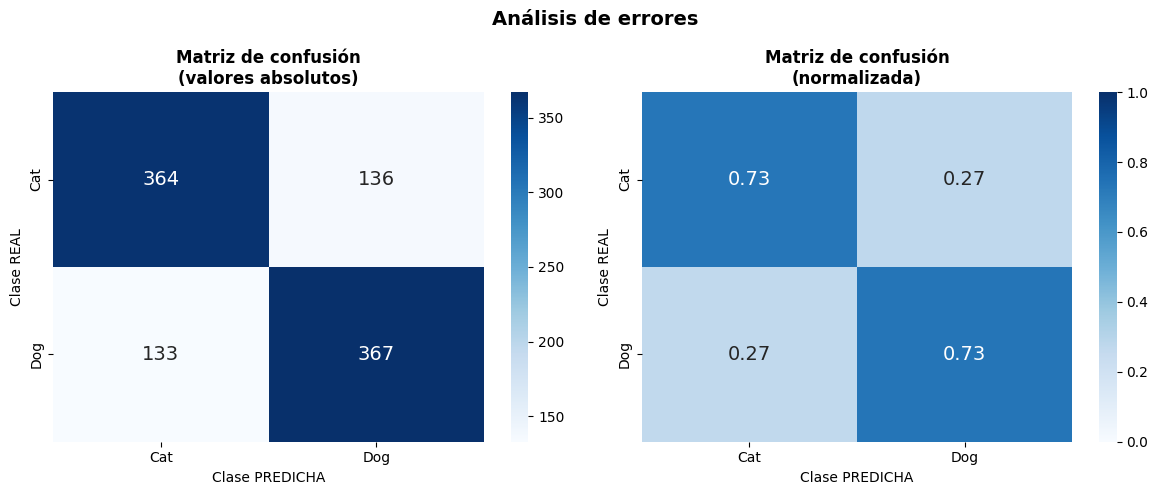


  Verdaderos Negativos (gatos bien):  364
  Falsos Positivos (gatos→perros):    136
  Falsos Negativos (perros→gatos):    133
  Verdaderos Positivos (perros bien): 367
SELECCIÓN DE IMÁGENES DIFÍCILES PARA EL CAPTCHA

 GATOS clasificados como PERROS (con alta confianza):
  Total errores (0→1): 136
  Seleccionadas (top 10%):      13 imágenes
  Confianza media del top:            0.949 (94.9%)
  Confianza mínima del top:           0.915 (91.5%)

 PERROS clasificados como GATOS (con alta confianza):
  Total errores (1→0): 133
  Seleccionadas (top 10%):      13 imágenes
  Confianza media del top:            0.989 (98.9%)
  Confianza mínima del top:           0.979 (97.9%)


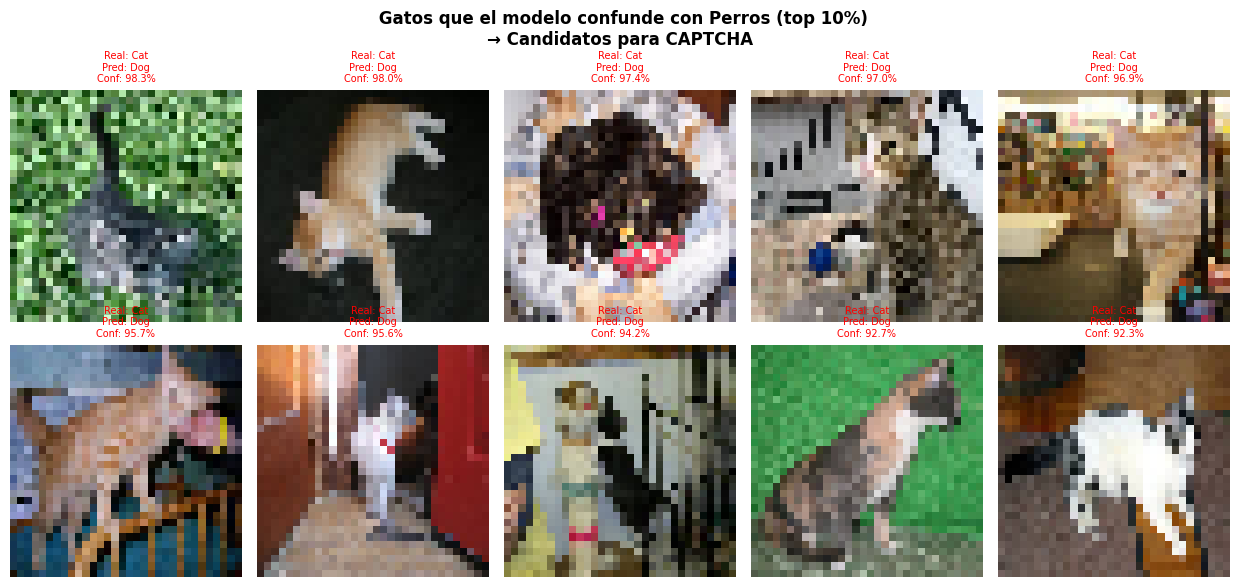

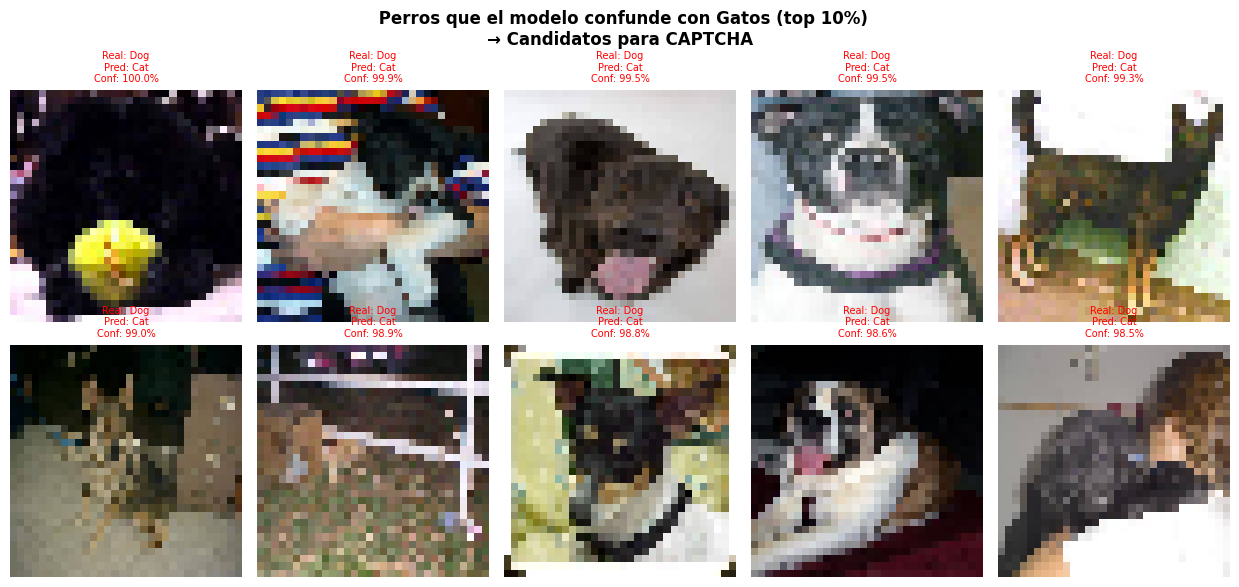

  Gatos→Perros seleccionados: 13
  Perros→Gatos seleccionados: 13
  TOTAL imágenes para CAPTCHA: 26


In [19]:


# PASO 4 - Evaluación, reporte y matriz de confusión


# --- 4.1 Evaluación global ---
test_loss, test_acc = model_cnn.evaluate(X_test_norm, y_test, verbose=0)
print(f"{'='*45}")
print(f"  Loss en test:      {test_loss:.4f}")
print(f"  Accuracy en test:  {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"{'='*45}")


# --- 4.2 Predicciones ---
# model.predict() devuelve probabilidades entre 0 y 1 (sigmoid)
# Un valor > 0.5 → predicción = perro (1)
# Un valor < 0.5 → predicción = gato (0)
probabilidades = model_cnn.predict(X_test_norm, verbose=0).flatten()
# .flatten() convierte shape (1000,1) → (1000,)

predicciones = (probabilidades > 0.5).astype(int)

# Nivel de confianza: qué tan seguro está el modelo de su predicción
# Si prob=0.9 → 90% seguro de que es perro
# Si prob=0.1 → 90% seguro de que es gato (1-0.1=0.9)
confianza = np.where(predicciones == 1, probabilidades, 1 - probabilidades)


# --- 4.3 Classification Report ---
print("\nClassification Report:")
print(classification_report(
    y_test,
    predicciones,
    target_names=['Cat (0)', 'Dog (1)']
))


# --- 4.4 Matriz de confusión ---
def plot_confusion_matrix_binaria(y_true, y_pred, class_names=['Cat', 'Dog']):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Absoluta
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0], annot_kws={'size': 14})
    axes[0].set_title('Matriz de confusión\n(valores absolutos)',
                      fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Clase REAL')
    axes[0].set_xlabel('Clase PREDICHA')

    # Normalizada
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], vmin=0, vmax=1, annot_kws={'size': 14})
    axes[1].set_title('Matriz de confusión\n(normalizada)',
                      fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Clase REAL')
    axes[1].set_xlabel('Clase PREDICHA')

    plt.suptitle('Análisis de errores', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Desglose numérico
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{'='*45}")
    print(f"  Verdaderos Negativos (gatos bien):  {tn}")
    print(f"  Falsos Positivos (gatos→perros):    {fp}")
    print(f"  Falsos Negativos (perros→gatos):    {fn}")
    print(f"  Verdaderos Positivos (perros bien): {tp}")
    print(f"{'='*45}")

plot_confusion_matrix_binaria(y_test, predicciones)


# PASO 5 - Selección de imágenes difíciles para el CAPTCHA

# Buscamos dos grupos:
# Grupo A: imágenes REALES de gato, clasificadas como perro, con mayor confianza
# Grupo B: imágenes REALES de perro, clasificadas como gato, con mayor confianza

def seleccionar_imagenes_dificiles(X, y_true, y_pred, probabilidades,
                                    clase_real, clase_predicha, porcentaje=0.10):
    """
    Selecciona el % de imágenes mal clasificadas con mayor confianza.

    Parámetros:
    -----------
    clase_real     : la clase verdadera de la imagen (0=cat, 1=dog)
    clase_predicha : la clase que el modelo predijo erróneamente
    porcentaje     : fracción a seleccionar (0.10 = 10%)
    """
    # Máscara: imágenes donde la clase real es 'clase_real'
    # Y la predicción es 'clase_predicha' (error)
    mascara_errores = (y_true == clase_real) & (y_pred == clase_predicha)
    indices_errores = np.where(mascara_errores)[0]

    if len(indices_errores) == 0:
        print("No hay errores de este tipo.")
        return np.array([])

    # Confianza de cada error: probabilidad de ser perro (clase 1)
    # Si predijo perro (1) → la confianza es directamente la probabilidad
    # Si predijo gato (0) → la confianza es 1 - probabilidad
    if clase_predicha == 1:
        # El modelo dijo "perro" → usamos la probabilidad directamente
        conf_errores = probabilidades[indices_errores]
    else:
        # El modelo dijo "gato" → la confianza de ser gato es 1-prob
        conf_errores = 1 - probabilidades[indices_errores]

    # Ordenamos por confianza DESCENDENTE (los más seguros primero)
    orden = np.argsort(conf_errores)[::-1]
    indices_ordenados = indices_errores[orden]
    conf_ordenada     = conf_errores[orden]

    # Cogemos el top 10%
    n_seleccionar = max(1, int(len(indices_ordenados) * porcentaje))
    indices_top   = indices_ordenados[:n_seleccionar]
    conf_top      = conf_ordenada[:n_seleccionar]

    print(f"  Total errores ({clase_real}→{clase_predicha}): {len(indices_errores)}")
    print(f"  Seleccionadas (top {porcentaje*100:.0f}%):      {n_seleccionar} imágenes")
    print(f"  Confianza media del top:            {conf_top.mean():.3f} ({conf_top.mean()*100:.1f}%)")
    print(f"  Confianza mínima del top:           {conf_top.min():.3f} ({conf_top.min()*100:.1f}%)")

    return indices_top, conf_top



print("SELECCIÓN DE IMÁGENES DIFÍCILES PARA EL CAPTCHA")


# --- Grupo A: gatos clasificados como perros ---
print("\n GATOS clasificados como PERROS (con alta confianza):")
indices_cat_as_dog, conf_cat_as_dog = seleccionar_imagenes_dificiles(
    X_test_norm, y_test, predicciones, probabilidades,
    clase_real=0, clase_predicha=1, porcentaje=0.10
)

# --- Grupo B: perros clasificados como gatos ---
print("\n PERROS clasificados como GATOS (con alta confianza):")
indices_dog_as_cat, conf_dog_as_cat = seleccionar_imagenes_dificiles(
    X_test_norm, y_test, predicciones, probabilidades,
    clase_real=1, clase_predicha=0, porcentaje=0.10
)


# --- Visualización de las imágenes seleccionadas ---
def visualizar_captcha_dificil(X, indices, confianzas, titulo, clase_real,
                                clase_predicha, class_names={0:'Cat', 1:'Dog'},
                                n_mostrar=10):
    n = min(n_mostrar, len(indices))
    cols = 5
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.5, rows*3))
    axes = np.array(axes).flatten()

    for i in range(n):
        idx = indices[i]
        axes[i].imshow(X[idx])
        axes[i].set_title(
            f"Real: {class_names[clase_real]}\n"
            f"Pred: {class_names[clase_predicha]}\n"
            f"Conf: {confianzas[i]*100:.1f}%",
            fontsize=7, color='red'
        )
        axes[i].axis('off')

    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.suptitle(titulo, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


visualizar_captcha_dificil(
    X_test_norm, indices_cat_as_dog, conf_cat_as_dog,
    " Gatos que el modelo confunde con Perros (top 10%)\n→ Candidatos para CAPTCHA",
    clase_real=0, clase_predicha=1
)

visualizar_captcha_dificil(
    X_test_norm, indices_dog_as_cat, conf_dog_as_cat,
    " Perros que el modelo confunde con Gatos (top 10%)\n→ Candidatos para CAPTCHA",
    clase_real=1, clase_predicha=0
)

# --- Resumen final ---
total_seleccionadas = len(indices_cat_as_dog) + len(indices_dog_as_cat)


print(f"  Gatos→Perros seleccionados: {len(indices_cat_as_dog)}")
print(f"  Perros→Gatos seleccionados: {len(indices_dog_as_cat)}")
print(f"  TOTAL imágenes para CAPTCHA: {total_seleccionadas}")
print(f"{'='*50}")